# Mock Member Health Analysis - Model_interpretation

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group,high_cost_member,has_acute_utilization,chronic_burden_group
0,M00001,69,Female,Rural,DSNP,3,72.6,1,1,2634.13,0,Q4,65-79,True,1,Moderate
1,M00002,32,Female,Suburban,Medicare Advantage,0,71.5,0,1,1632.38,1,Q4,18-34,False,1,Low
2,M00003,89,Male,Suburban,Medicaid,2,32.6,0,0,978.36,1,Q1,80+,False,0,Moderate
3,M00004,78,Male,Suburban,Medicare Advantage,7,56.0,3,0,2761.83,1,Q3,65-79,True,1,High
4,M00005,38,Female,Urban,DSNP,2,42.2,0,1,2001.45,1,Q1,35-49,True,1,Moderate


In [6]:
target = "awv_completed"

X = df.drop(columns = ["member_id", target])
y = df[target]

## 3. Rebuild Baseline Logistic Regression

In [7]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)


In [8]:
categorical_cols = X.select_dtypes(include = ["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include = ["int64", "float64", "int32", "float32"]).columns.tolist()

C:\Users\kdy10\AppData\Local\Temp\ipykernel_27084\1447402273.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include = ["object", "category"]).columns.tolist()


In [ ]:
#Preprocessor

preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop="first", handle_unknown = "ignore"), categorical_cols),
         ("num", "passthrough", numeric_cols)
    ]
)


In [ ]:
log_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])
log_model.fit(X_train, y_train)

## 4.Review Class Balance

In [24]:
df["awv_completed"].value_counts(normalize = True)


awv_completed
1    0.696
0    0.304
Name: proportion, dtype: float64

## 5. Evaluate Predictions More Deeply

In [25]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [27]:
print("Accuracy", accuracy_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy 0.71
Precision 0.735632183908046
Recall 0.9142857142857143
F1 Score 0.8152866242038217
ROC AUC: 0.6533333333333333

Confusion Matrix:
[[ 7 23]
 [ 6 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.23      0.33        30
           1       0.74      0.91      0.82        70

    accuracy                           0.71       100
   macro avg       0.64      0.57      0.57       100
weighted avg       0.68      0.71      0.67       100



## 6.Interpret Logistic Regression Coefficients

### Step A: get transformed feature names

In [28]:
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(encoded_cat_features) + numeric_cols

### Step B: get coefficients

In [29]:
coefficients = log_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending = False)

coef_df.head(15)


,feature,coefficient,abs_coefficient
10,age_group_65-79,-0.649732,0.649732
5,engagement_group_Q2,0.405322,0.405322
11,age_group_80+,0.373398,0.373398
0,gender_Male,0.271510,0.271510
12,chronic_burden_group_Low,0.265277,0.265277
2,region_Urban,0.217658,0.217658
17,ed_visits,-0.207230,0.207230
8,age_group_35-49,0.117395,0.117395
1,region_Suburban,-0.100555,0.100555
15,chronic_condition_count,0.077665,0.077665


## 7. Test Different Classification Threshold

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh, zero_division = 0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division = 0 ),
        "f1_score": f1_score(y_test, y_pred_thresh, zero_division = 0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


threshold    0.400000
accuracy     0.740000
precision    0.734043
recall       0.985714
f1_score     0.841463
Name: 1, dtype: float64

## 8. Compare Threshold Tradeoffs

In [35]:
best_f1_row = threshold_df.sort_values("f1_score", ascending = False).iloc[0]
best_f1_row


threshold    0.400000
accuracy     0.740000
precision    0.734043
recall       0.985714
f1_score     0.841463
Name: 1, dtype: float64

## Findings 

1. The Target Variable is imbalanced toward AWV-completed members, so accuracy alone overstates model quality.
2. Logistic regression shows which features are postiviely or negatively associated with predicted AWV completion
3. Engagement-related variables appear to support higher predicted AWV completion, which is consistent with the synthetic data design.
4. Model performance changes meaningfully across classification thresholds, showing that the default 0.50 cutoff is only one operating choice.
5. These relationships reflect learned patterns in synthetic data and should not be interpreted as causal effects. 

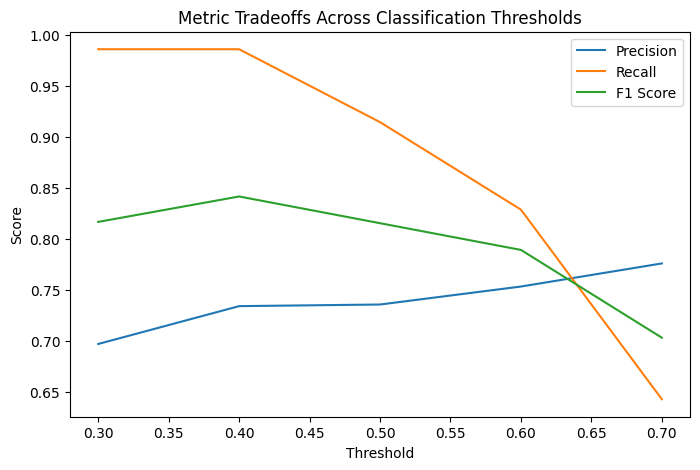

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metric Tradeoffs Across Classification Thresholds")
plt.legend()
plt.show()